# EDA — Bank Customer Churn

Análisis exploratorio del dataset `Bank_Churn.csv` (10.000 clientes de un banco europeo). Este notebook alimenta el pipeline principal **`Property_Oracle.ipynb`**: aquí exploramos, documentamos los hallazgos y exportamos la versión **curada** en `data/processed/bank_churn_clean.csv`.

## 1. Carga y exploración inicial

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/Bank_Churn.csv')
print('Dimensiones:', df.shape)
print('\nTipos de dato:\n', df.dtypes)

Dimensiones: (10000, 13)

Tipos de dato:
 CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


## 2. Calidad de datos
Verificamos nulos, duplicados y resúmenes de las variables numéricas antes de modelar.

In [2]:
# nulos y duplicados
print('Nulos por columna:')
print(df.isnull().sum())
print('\nFilas duplicadas:', df.duplicated().sum())

# resumen numerico (redondeado a 2 decimales)
print('\nResumen estadístico:')
print(df.describe().round(2))

Nulos por columna:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Filas duplicadas: 0

Resumen estadístico:
        CustomerId  CreditScore       Age    Tenure    Balance  NumOfProducts  \
count     10000.00     10000.00  10000.00  10000.00   10000.00       10000.00   
mean   15690940.57       650.53     38.92      5.01   76485.89           1.53   
std       71936.19        96.65     10.49      2.89   62397.41           0.58   
min    15565701.00       350.00     18.00      0.00       0.00           1.00   
25%    15628528.25       584.00     32.00      3.00       0.00           1.00   
50%    15690738.00       652.00     37.00      5.00   97198.54           1.00   
75%    15753233.75       718.00     44.00      7.00  127644.24           2.00   
max 

## 3. Balance de clases
El target `Exited` está desbalanceado (**79.63% se queda / 20.37% se va**). Ese desbalance hace que Accuracy sola no baste: hay que vigilar Recall y Precision.

Distribución del target Exited:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Baseline de Accuracy (predecir siempre 0): 79.63%


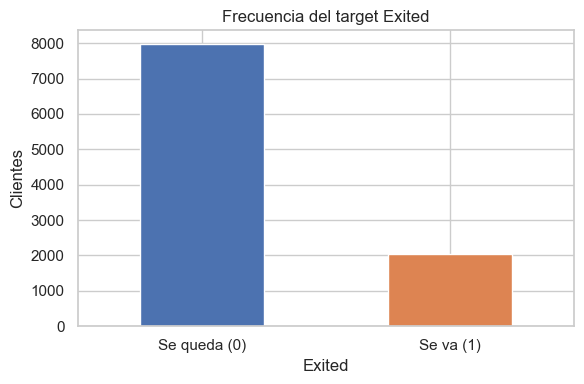

In [3]:
proporciones = df['Exited'].value_counts(normalize=True).round(4)
print('Distribución del target Exited:')
print(proporciones)
print(f'\nBaseline de Accuracy (predecir siempre 0): {proporciones[0]:.2%}')

# visual para el desbalance
fig, ax = plt.subplots(figsize=(6, 4))
df['Exited'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'], ax=ax)
ax.set_title('Frecuencia del target Exited')
ax.set_xticklabels(['Se queda (0)', 'Se va (1)'], rotation=0)
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.show()

## 4. Análisis bivariado: qué distingue al cliente que se va
Comparaciones directas entre quien se queda y quien se va.

In [4]:
# tasa de bajas por país
baja_pais = (df.groupby('Geography')['Exited']
               .agg(['count', 'mean']).rename(columns={'count': 'Clientes', 'mean': 'Tasa de bajas'}).round(4))
print('--- Bajas por país ---')
print(baja_pais)

# edad media y miembros activos según que se vaya o no
grupo = df.groupby('Exited').agg(Edad_media=('Age', 'mean'),
                                 Miembros_activos=('IsActiveMember', 'mean'),
                                 CreditScore_medio=('CreditScore', 'mean')).round(3)
grupo.index = ['Se queda (0)', 'Se va (1)']
print('\n--- Edad / actividad / credit score según Exited ---')
print(grupo)

# NumOfProducts: relacion no lineal con el churn
prod = df.groupby('NumOfProducts')['Exited'].mean().round(4)
print('\n--- Tasa de bajas por número de productos ---')
print(prod)

--- Bajas por país ---
           Clientes  Tasa de bajas
Geography                         
France         5014         0.1615
Germany        2509         0.3244
Spain          2477         0.1667

--- Edad / actividad / credit score según Exited ---
              Edad_media  Miembros_activos  CreditScore_medio
Se queda (0)      37.408             0.555            651.853
Se va (1)         44.838             0.361            645.351

--- Tasa de bajas por número de productos ---
NumOfProducts
1    0.2771
2    0.0758
3    0.8271
4    1.0000
Name: Exited, dtype: float64


## 5. Curaduría y exportación

Decisiones documentadas:
- **`CustomerId` y `Surname`** son identificadores sin poder predictivo (memorizarían clientes). Se eliminan.
- **`Geography`** (France/Spain/Germany) y **`Gender`** (Male/Female) se codifican one-hot
- `NumOfProducts` se conserva **numérico**: su relación es no lineal y la dejamos para que el modelo lineal capture la señal dominante.
El resultado queda **sin nulos** y listo para que `Property_Oracle.ipynb` lo use directo.

In [5]:
df_clean = df.drop(columns=['CustomerId', 'Surname']) # columnas que podrian memorizarse

df_clean = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=True) # destruimos esas columnas y las seccionamos, sin trampa de dummy (k-1)
for c_ in df_clean.select_dtypes(include='bool').columns:
    df_clean[c_] = df_clean[c_].astype(int)

import os

os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/bank_churn_clean.csv', index=False)

print('Exportado: ../data/processed/bank_churn_clean.csv')
print('Dimensiones curate:', df_clean.shape)
print('Nulos restantes:', int(df_clean.isnull().sum().sum()))
print('\nColumnas finales:', df_clean.columns.tolist())

Exportado: ../data/processed/bank_churn_clean.csv
Dimensiones curate: (10000, 12)
Nulos restantes: 0

Columnas finales: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


## Hallazgos resumen

- **Desbalance**: 79.63/20.37 → Accuracy base = 0.80; Recall/Presisión son las métricas que importan.
- **`Age`** es el predictor más fuerte: el que se va tiene ~44.8 años vs ~37.4 del que se queda.
- **`Geography_Germany`** concentra el 32% de las bajas (≈el doble de Francia/España): región importa.
- **`IsActiveMember`** es protector: 0.64 de activos entre los que se quedan vs 0.36 entre los que se van.
- **`NumOfProducts`** no es lineal: 0, 1, 3, 4 productos concentran más fuga que 2.
- El dataset no tiene nulos; la curaduría solo descarta identificadores y codifica categóricas.